In [113]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src/')

In [114]:
import utils
import importlib
importlib.reload(utils)

<module 'utils' from 'C:\\Users\\ysvad\\Desktop\\Academics\\Thesis\\Final_Code_Database\\Notebooks\\../src\\utils.py'>

In [115]:
h = 0.67 

Om_m = 0.315            # matter density
Om_b = 0.022/(h*h)      # baryonic matter density
#Om_lambda = 0.685       # vacuum energy density

Om_lambda = 0

rho_c = 2.78e11 *h*h    # in units of M_s/Mpc^3

# mean matter density of the universe
rho_0 = Om_m * rho_c    # in units of M_s/Mpc^3
delta_c = 1.686         # Critical density for spherical collapse

# for normalising the power spectrum
sigma8_obs = 0.811      # Observed value of sigma_8
n = 0.965               # power spectrum P(k)~ k^n

# Cosmological Reionization

Barkana and Loeb (2001):

$$\frac{\text{d}f_\text{HII}}{\text{d}z}=\frac{\dot{N}_\gamma}{n_\text{H}(z)}\frac{\text{d}t}{\text{d}z}-\alpha_\text{B}n_\text{H}(z)f_\text{HII}C\frac{\text{d}t}{\text{d}z}$$

where:

$$\dot{N}_\gamma=\frac{\dot{\rho}_\text{SF}(z)(1+z)^3}{m_\text{p}}n_\gamma f_\text{esc}$$

## Our SFRDs

In [116]:
from utils import z_range

In [117]:
#Epsilon = 0.02

SFRs, SFR1s, SFR2s = np.genfromtxt("../Data/OurSFRsData.csv", unpack = True, delimiter = ",", skip_header = 1)

In [118]:
#Test SFRs

SFRs = 10 ** (-3)

In [119]:
#Epsilon = 0.05

SFRs_2, SFR1s_2, SFR2s_2 = np.genfromtxt("../Data/OurSFRsData2.csv", unpack = True, delimiter = ",", skip_header = 1)

In [120]:
#Solving for dN_gamma/dt:

n_gamma = 4800 #Number of ionizing photons produced per baryon (proton), dimensionless
n_gamma2 = 7780
f_esc = 0.1 #Fraction of photons escaping the star forming halo
f_esc2 = 0.2
m_p = 1.67 * 10 ** (-27) * 5.03 * 10 ** (-31) #mass of proton in Solar Masses

def dN_dt_func(SFRD, z_arr, n_gamma_val, f_esc_val):
    return SFRD * (1 + z_arr) ** 3 * n_gamma_val * f_esc_val / m_p

#Rate of UV photon escpae into IGM (dN_gamma/dt) for each SFRD in yr^-1 Mpc^-3

#Set 1
dN_dt = dN_dt_func(SFRs, z_range, n_gamma2, f_esc)
dN_dt2 = dN_dt_func(SFR2s, z_range, n_gamma2, f_esc)
dN_dt3 = dN_dt_func(SFR2s, z_range, n_gamma, f_esc2)

#Set 2

dN_dt_2 = dN_dt_func(SFRs_2, z_range, n_gamma, f_esc)
dN_dt2_2 = dN_dt_func(SFR1s_2, z_range, n_gamma2, f_esc)
dN_dt3_2 = dN_dt_func(SFR2s_2, z_range, n_gamma2, f_esc)

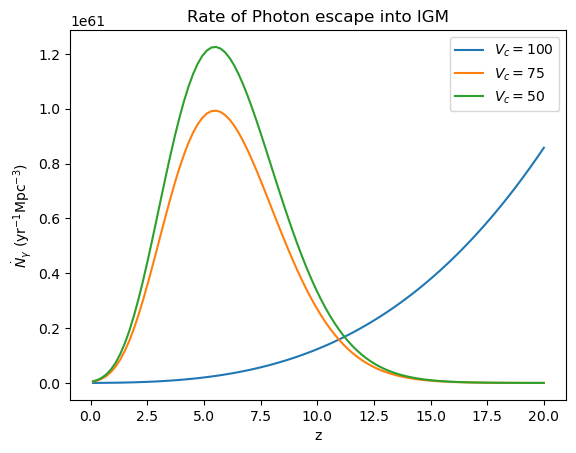

In [121]:
plt.plot(z_range, dN_dt, label=r"$V_c = 100$")
plt.plot(z_range, dN_dt2, label=r"$V_c = 75$")
plt.plot(z_range, dN_dt3, label=r"$V_c = 50$")
plt.title(r'Rate of Photon escape into IGM')
plt.ylabel(r'$\dot{N}_\gamma$ (yr$^{-1}$Mpc$^{-3}$)')
plt.xlabel(r'z')
plt.legend()
plt.show()

In [122]:
from utils import H

In [123]:
#Parameters in the reionization equation
X_H = 0.75 #Fraction of hydrogen
alpha_B = 2.59 * 10 ** (-13) #Case B recombination coefficient at T=3*10^4 K in cm^3 * s^-1

alpha_B_unit = alpha_B * (3.24 * 10 ** (-25)) ** 3 / (3.17 * 10 ** (-8)) #Coefficient in Mpc^3 * yr^-1

def n_H(z): #Mean proper number denisty of hydrogen atoms in Mpc^-3
    return X_H * Om_b * rho_c * (1 + z) ** 3 / m_p

def dt_dz(z): #In yr
    return -1 / ((1 + z) * H(z))

def Haiman_Clump(z): # Clumping factor (dimensionless), Haiman and Bryan (2006)
    if z >= 6:
        return 1 + 9 * (7 / (1 + z)) ** 2
    else:
        return 10

def Test_Clump(z):
    return 10

def Madau_Clump(z):
    return 2.9 * ((1 + z) / 6) ** (-1.1)

In [124]:
z_step_length_arr = np.diff(z_range)
step_length = z_step_length_arr[0] #Step length for RK-4 integrator

step_length

np.float64(0.201010101010101)

In [125]:
from scipy.interpolate import CubicSpline

In [126]:
#Interpolated dN_dt for h/2 timestep to use in RK-4 fpr Set 1

CS = CubicSpline(z_range, dN_dt) #Cubic spline function for dN_dt

z_interped = z_range - step_length / 2 #All values of z at which dN_dt needs to be interpolated
dN_dt_interped = np.zeros_like(z_interped) #dN_dt interpolated value array, to be filled

for i in range(len(z_interped)): #Filling in the interpolated dN_dt values array
    dN_dt_interped[i] = CS(z_interped[i])

#Generating the final z array with original and final values
z_final = np.empty(z_interped.size + z_range.size, dtype=z_interped.dtype)
z_final[0::2] = z_interped
z_final[1::2] = z_range

#Generating the final dN_dt array with original and final values
dN_dt_final = np.empty(dN_dt_interped.size + dN_dt.size, dtype=dN_dt_interped.dtype)
dN_dt_final[0::2] = dN_dt_interped
dN_dt_final[1::2] = dN_dt

CS2 = CubicSpline(z_range, dN_dt2) #Cubic spline function for dN_dt
dN_dt_interped2 = np.zeros_like(z_interped) #dN_dt interpolated value array, to be filled
for i in range(len(z_interped)): #Filling in the interpolated dN_dt values array
    dN_dt_interped2[i] = CS2(z_interped[i])
#Generating the final dN_dt array with original and final values
dN_dt_final2 = np.empty(dN_dt_interped2.size + dN_dt2.size, dtype=dN_dt_interped2.dtype)
dN_dt_final2[0::2] = dN_dt_interped2
dN_dt_final2[1::2] = dN_dt2

CS3 = CubicSpline(z_range, dN_dt3) #Cubic spline function for dN_dt
dN_dt_interped3 = np.zeros_like(z_interped) #dN_dt interpolated value array, to be filled
for i in range(len(z_interped)): #Filling in the interpolated dN_dt values array
    dN_dt_interped3[i] = CS3(z_interped[i])
#Generating the final dN_dt array with original and final values
dN_dt_final3 = np.empty(dN_dt_interped3.size + dN_dt3.size, dtype=dN_dt_interped3.dtype)
dN_dt_final3[0::2] = dN_dt_interped3
dN_dt_final3[1::2] = dN_dt3

In [127]:
#Interpolated dN_dt for h/2 timestep to use in RK-4 for Set 2

CS_2 = CubicSpline(z_range, dN_dt_2) #Cubic spline function for dN_dt

z_interped = z_range - step_length / 2 #All values of z at which dN_dt needs to be interpolated
dN_dt_interped_2 = np.zeros_like(z_interped) #dN_dt interpolated value array, to be filled

for i in range(len(z_interped)): #Filling in the interpolated dN_dt values array
    dN_dt_interped_2[i] = CS_2(z_interped[i])

#Generating the final z array with original and final values
z_final = np.empty(z_interped.size + z_range.size, dtype=z_interped.dtype)
z_final[0::2] = z_interped
z_final[1::2] = z_range

#Generating the final dN_dt array with original and final values
dN_dt_final_2 = np.empty(dN_dt_interped_2.size + dN_dt_2.size, dtype=dN_dt_interped_2.dtype)
dN_dt_final_2[0::2] = dN_dt_interped_2
dN_dt_final_2[1::2] = dN_dt_2

CS2_2 = CubicSpline(z_range, dN_dt2_2) #Cubic spline function for dN_dt
dN_dt_interped2_2 = np.zeros_like(z_interped) #dN_dt interpolated value array, to be filled
for i in range(len(z_interped)): #Filling in the interpolated dN_dt values array
    dN_dt_interped2_2[i] = CS2(z_interped[i])
#Generating the final dN_dt array with original and final values
dN_dt_final2_2 = np.empty(dN_dt_interped2_2.size + dN_dt2_2.size, dtype=dN_dt_interped2_2.dtype)
dN_dt_final2_2[0::2] = dN_dt_interped2_2
dN_dt_final2_2[1::2] = dN_dt2_2

CS3_2 = CubicSpline(z_range, dN_dt3_2) #Cubic spline function for dN_dt
dN_dt_interped3_2 = np.zeros_like(z_interped) #dN_dt interpolated value array, to be filled
for i in range(len(z_interped)): #Filling in the interpolated dN_dt values array
    dN_dt_interped3_2[i] = CS3(z_interped[i])
#Generating the final dN_dt array with original and final values
dN_dt_final3_2 = np.empty(dN_dt_interped3_2.size + dN_dt3_2.size, dtype=dN_dt_interped3_2.dtype)
dN_dt_final3_2[0::2] = dN_dt_interped3_2
dN_dt_final3_2[1::2] = dN_dt3_2

In [128]:
#Reversing z and dN_dt for integration order from high to low redshift for Set 1
reversed_z = z_final[::-1]
reversed_dN_dt = dN_dt_final[::-1]
reversed_dN_dt2 = dN_dt_final2[::-1]
reversed_dN_dt3 = dN_dt_final3[::-1]
reversed_input_z = z_range[::-1]

#Defining RHS for reionization equation:
def RHS_SFRs(z, N_g_dot, f_HII, C_model):
    return N_g_dot / n_H(z) * dt_dz(z) - alpha_B_unit * n_H(z) * f_HII * C_model(z) * dt_dz(z)

In [129]:
#Reversing z and dN_dt for integration order from high to low redshift for Set 2
reversed_z = z_final[::-1]
reversed_dN_dt_2 = dN_dt_final_2[::-1]
reversed_dN_dt2_2 = dN_dt_final2_2[::-1]
reversed_dN_dt3_2 = dN_dt_final3_2[::-1]
reversed_input_z = z_range[::-1]

In [130]:
#Set 1

even_index_array = reversed_dN_dt[0::2]  # indices 0, 2, 4, ...
odd_index_array  = reversed_dN_dt[1::2]  # indices 1, 3, 5, ...

even_index_array2 = reversed_dN_dt2[0::2]  # indices 0, 2, 4, ...
odd_index_array2  = reversed_dN_dt2[1::2]  # indices 1, 3, 5, ...

even_index_array3 = reversed_dN_dt3[0::2]  # indices 0, 2, 4, ...
odd_index_array3  = reversed_dN_dt3[1::2]  # indices 1, 3, 5, ...
"""
np.savetxt(
    "dataEven.csv",
    even_index_array,
    delimiter=",",
    fmt="%.6f"   # IMPORTANT: avoids scientific notation in Excel
)
"""

'\nnp.savetxt(\n    "dataEven.csv",\n    even_index_array,\n    delimiter=",",\n    fmt="%.6f"   # IMPORTANT: avoids scientific notation in Excel\n)\n'

In [131]:
#Set 2

even_index_array_2 = reversed_dN_dt_2[0::2]  # indices 0, 2, 4, ...
odd_index_array_2  = reversed_dN_dt_2[1::2]  # indices 1, 3, 5, ...

even_index_array2_2 = reversed_dN_dt2_2[0::2]  # indices 0, 2, 4, ...
odd_index_array2_2  = reversed_dN_dt2_2[1::2]  # indices 1, 3, 5, ...

even_index_array3_2 = reversed_dN_dt3_2[0::2]  # indices 0, 2, 4, ...
odd_index_array3_2  = reversed_dN_dt3_2[1::2]  # indices 1, 3, 5, ...
"""
np.savetxt(
    "dataEven.csv",
    even_index_array,
    delimiter=",",
    fmt="%.6f"   # IMPORTANT: avoids scientific notation in Excel
)
"""

'\nnp.savetxt(\n    "dataEven.csv",\n    even_index_array,\n    delimiter=",",\n    fmt="%.6f"   # IMPORTANT: avoids scientific notation in Excel\n)\n'

In [132]:
def RK4_OurModels(z_0, f_0, RHS, dN_dt_O, dN_dt_I, h, C_model): #h is positive, dN_dt specifically generated for z_range (0, 20)
    #dN_dt_O is uninterpolated dN_dt arr and dN_dt_I is only the interpolated values (both from high to low redshift)
    steps = len(z_range)
    z_arr = np.zeros(steps)
    z_arr[0] = z_0
    f_arr = np.zeros_like(z_arr)
    f_arr[0] = f_0
    for i in range(steps):
        N_g_dot_val = dN_dt_O[i] #dN_dt vals at z_range vals
        N_g_dot_val_int = dN_dt_I[i] #dN_dt vals at interpolated z_range - h / 2 vals
        N_g_dot_val_int2 = dN_dt_O[i + 1]
        k_1 = RHS(z_arr[i], N_g_dot_val, f_arr[i], C_model)
        k_2 = RHS(z_arr[i] - h / 2, N_g_dot_val_int, f_arr[i] - h * k_1 / 2, C_model)
        k_3 = RHS(z_arr[i] - h / 2, N_g_dot_val_int, f_arr[i] - h * k_2 / 2, C_model)
        k_4 = RHS(z_arr[i] - h, N_g_dot_val_int2, f_arr[i] - h * k_3, C_model)
        z_arr[i + 1] = z_arr[i] - h
        f_arr[i + 1] = f_arr[i] - h / 6 * (k_1 + 2 * k_2 + 2 * k_3 + k_4)
        if f_arr[i + 1] >= 1:
            for j in range(i + 1, steps):
                f_arr[j] = 1
            break
    z_arr_reversed = z_arr[::-1]
    f_arr_reversed = f_arr[::-1]
    return z_arr_reversed, f_arr_reversed

In [133]:
#Set 1, different clumping models

#Haiman_Clump
SFRs_dataHaiman = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array, even_index_array, step_length, Test_Clump)[1]
SFR2s_dataHaiman = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array2, even_index_array2, step_length, Haiman_Clump)[1]
SFR3s_dataHaiman = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array3, even_index_array3, step_length, Haiman_Clump)[1]

#Test_Clump
SFRs_dataTest = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array, even_index_array, step_length, Test_Clump)[1]
SFR2s_dataTest = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array2, even_index_array2, step_length, Test_Clump)[1]
SFR3s_dataTest = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array3, even_index_array3, step_length, Test_Clump)[1]

#Madau_Clump
SFRs_dataMadau = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array, even_index_array, step_length, Madau_Clump)[1]
SFR2s_dataMadau = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array2, even_index_array2, step_length, Madau_Clump)[1]
SFR3s_dataMadau = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array3, even_index_array3, step_length, Madau_Clump)[1]

In [134]:
#Set 2, different clumping models

#Haiman_Clump
SFRs_dataHaiman_2 = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array_2, even_index_array_2, step_length, Haiman_Clump)[1]
SFR2s_dataHaiman_2 = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array2_2, even_index_array2_2, step_length, Haiman_Clump)[1]
SFR3s_dataHaiman_2 = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array3_2, even_index_array3_2, step_length, Haiman_Clump)[1]

#Test_Clump
SFRs_dataTest_2 = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array_2, even_index_array_2, step_length, Test_Clump)[1]
SFR2s_dataTest_2 = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array2_2, even_index_array2_2, step_length, Test_Clump)[1]
SFR3s_dataTest_2 = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array3_2, even_index_array3_2, step_length, Test_Clump)[1]

#Madau_Clump
SFRs_dataMadau_2 = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array_2, even_index_array_2, step_length, Madau_Clump)[1]
SFR2s_dataMadau_2 = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array2_2, even_index_array2_2, step_length, Madau_Clump)[1]
SFR3s_dataMadau_2 = RK4_OurModels(20, 0, RHS_SFRs, odd_index_array3_2, even_index_array3_2, step_length, Madau_Clump)[1]

## Reionization Datapoints from Literature

In [135]:
#Umeda et al. 2025

z_lit_vals = np.array([5, 5.8, 7, 8.6, 10.4])
x_I_vals = np.array([0, 0.25, 0.65, 1, 1]) #1-f_HII
f_HII_vals = 1 - x_I_vals
Low_Err_f_HII = np.array([0.12, 0.10, 0.27, 0, 0])
Upp_Err_f_HII = np.array([0, 0.2, 0.35, 0.2, 0.4])

In [136]:
z_lit_vals2, x_I_vals2 = np.genfromtxt("../Data/Cosm_Reion_LitPoints_Umeda.csv", unpack = True, delimiter = ",", skip_header = 1)

f_HII_vals2 = 1 - x_I_vals2

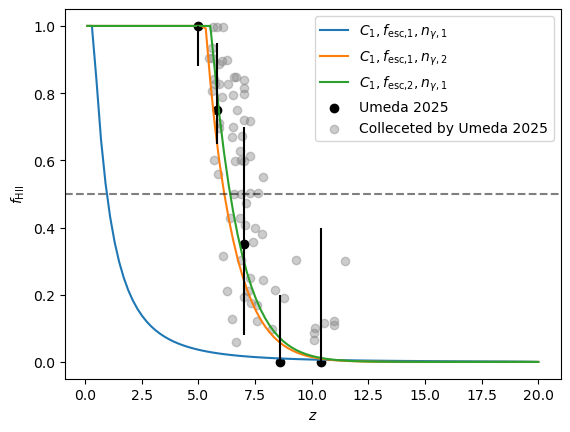

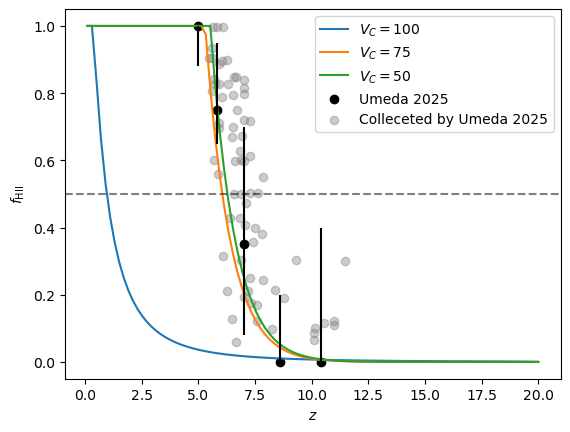

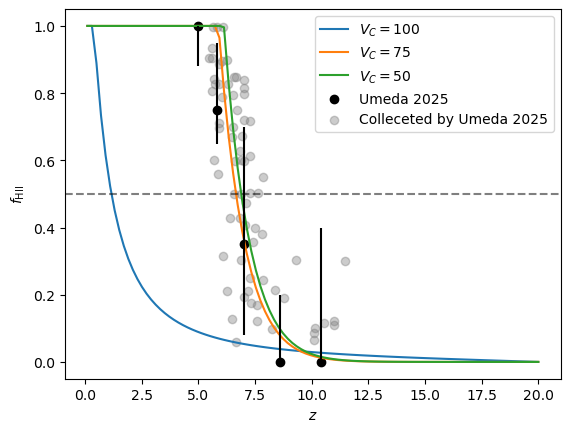

In [137]:
#Set 1 curves

plt.plot(z_range, SFRs_dataHaiman, label = r'$C_1, f_\text{esc,1}, n_{\gamma,1}$')
plt.plot(z_range, SFR2s_dataHaiman, label = r'$C_1, f_\text{esc,1}, n_{\gamma,2}$')
plt.plot(z_range, SFR3s_dataHaiman, label = r'$C_1, f_\text{esc,2}, n_{\gamma,1}$')
plt.xlabel(r'$z$')
plt.ylabel(r'$f_\text{HII}$')
plt.axhline(0.5, ls = '--', color = r'black', alpha = 0.5)
#plt.axvline(5, ls = '--', color = r'firebrick')
#plt.axvline(6, ls = '--', color = r'firebrick')
#plt.axvline(7, ls = '--', color = r'firebrick')

plt.scatter(z_lit_vals, f_HII_vals, color = r'Black', label = r'Umeda 2025')
plt.scatter(z_lit_vals2, f_HII_vals2, color = r'gray', alpha = 0.4, label = r'Colleceted by Umeda 2025')
plt.errorbar(z_lit_vals, f_HII_vals, yerr = np.array([Low_Err_f_HII, Upp_Err_f_HII]), color = r'black', fmt = ' ')
plt.legend()
plt.show()

plt.plot(z_range, SFRs_dataTest, label = r'$V_C=100$')
plt.plot(z_range, SFR2s_dataTest, label = r'$V_C=75$')
plt.plot(z_range, SFR3s_dataTest, label = r'$V_C=50$')
plt.xlabel(r'$z$')
plt.ylabel(r'$f_\text{HII}$')
plt.axhline(0.5, ls = '--', color = r'black', alpha = 0.5)
#plt.axvline(5, ls = '--', color = r'firebrick')
#plt.axvline(6, ls = '--', color = r'firebrick')
#plt.axvline(7, ls = '--', color = r'firebrick')

plt.scatter(z_lit_vals, f_HII_vals, color = r'Black', label = r'Umeda 2025')
plt.scatter(z_lit_vals2, f_HII_vals2, color = r'gray', alpha = 0.4, label = r'Colleceted by Umeda 2025')
plt.errorbar(z_lit_vals, f_HII_vals, yerr = np.array([Low_Err_f_HII, Upp_Err_f_HII]), color = r'black', fmt = ' ')
plt.legend()
plt.show()

plt.plot(z_range, SFRs_dataMadau, label = r'$V_C=100$')
plt.plot(z_range, SFR2s_dataMadau, label = r'$V_C=75$')
plt.plot(z_range, SFR3s_dataMadau, label = r'$V_C=50$')
plt.xlabel(r'$z$')
plt.ylabel(r'$f_\text{HII}$')
plt.axhline(0.5, ls = '--', color = r'black', alpha = 0.5)
#plt.axvline(5, ls = '--', color = r'firebrick')
#plt.axvline(6, ls = '--', color = r'firebrick')
#plt.axvline(7, ls = '--', color = r'firebrick')

plt.scatter(z_lit_vals, f_HII_vals, color = r'Black', label = r'Umeda 2025')
plt.scatter(z_lit_vals2, f_HII_vals2, color = r'gray', alpha = 0.4, label = r'Colleceted by Umeda 2025')
plt.errorbar(z_lit_vals, f_HII_vals, yerr = np.array([Low_Err_f_HII, Upp_Err_f_HII]), color = r'black', fmt = ' ')
plt.legend()
plt.show()

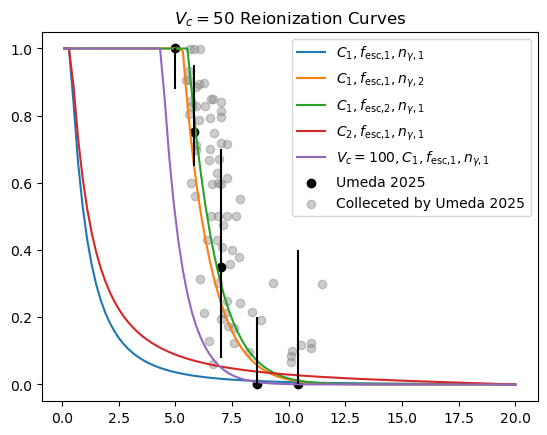

In [138]:
plt.plot(z_range, SFRs_dataHaiman, label = r'$C_1, f_\text{esc,1}, n_{\gamma,1}$')
plt.plot(z_range, SFR2s_dataHaiman, label = r'$C_1, f_\text{esc,1}, n_{\gamma,2}$')
plt.plot(z_range, SFR3s_dataHaiman, label = r'$C_1, f_\text{esc,2}, n_{\gamma,1}$')
plt.plot(z_range, SFRs_dataMadau, label = r'$C_2, f_\text{esc,1}, n_{\gamma,1}$')
plt.plot(z_range, SFRs_dataHaiman_2, label = r'$V_c=100, C_1, f_\text{esc,1}, n_{\gamma,1}$')
plt.scatter(z_lit_vals, f_HII_vals, color = r'Black', label = r'Umeda 2025')
plt.scatter(z_lit_vals2, f_HII_vals2, color = r'gray', alpha = 0.4, label = r'Colleceted by Umeda 2025')
plt.errorbar(z_lit_vals, f_HII_vals, yerr = np.array([Low_Err_f_HII, Upp_Err_f_HII]), color = r'black', fmt = ' ')
plt.legend()
plt.title(r'$V_c=50$ Reionization Curves')
plt.show()

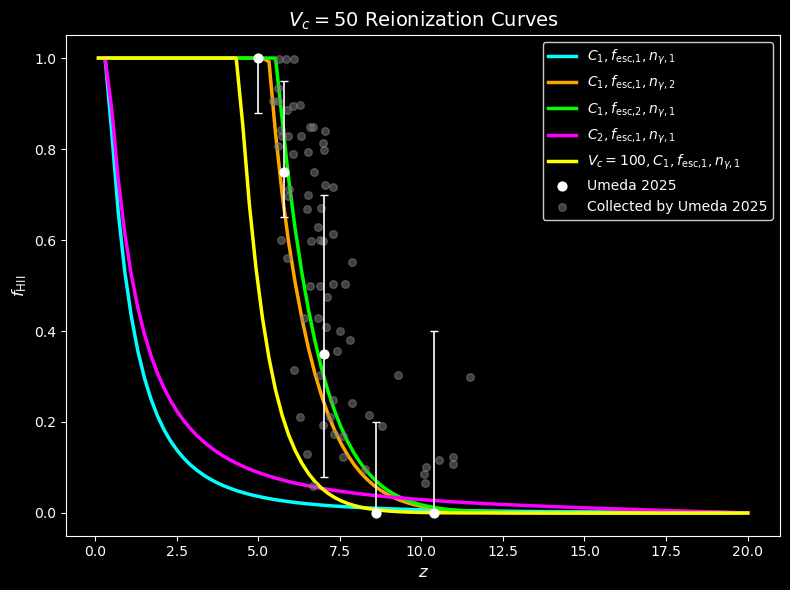

In [139]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Curves ---
ax.plot(z_range, SFRs_dataHaiman,
        label=r'$C_1, f_\text{esc,1}, n_{\gamma,1}$',
        color='#00FFFF', lw=2.5)

ax.plot(z_range, SFR2s_dataHaiman,
        label=r'$C_1, f_\text{esc,1}, n_{\gamma,2}$',
        color='#FFA500', lw=2.5)

ax.plot(z_range, SFR3s_dataHaiman,
        label=r'$C_1, f_\text{esc,2}, n_{\gamma,1}$',
        color='#00FF00', lw=2.5)

ax.plot(z_range, SFRs_dataMadau,
        label=r'$C_2, f_\text{esc,1}, n_{\gamma,1}$',
        color='#FF00FF', lw=2.5)

ax.plot(z_range, SFRs_dataHaiman_2,
        label=r'$V_c=100, C_1, f_\text{esc,1}, n_{\gamma,1}$',
        color='#FFFF00', lw=2.5)

# --- Scatter points ---
ax.scatter(z_lit_vals, f_HII_vals,
           color='white', s=40, label=r'Umeda 2025', zorder=3)

ax.scatter(z_lit_vals2, f_HII_vals2,
           color='gray', alpha=0.5, s=30,
           label=r'Collected by Umeda 2025', zorder=2)

# --- Error bars ---
ax.errorbar(z_lit_vals, f_HII_vals,
            yerr=np.array([Low_Err_f_HII, Upp_Err_f_HII]),
            fmt='none',
            ecolor='white',
            elinewidth=1.2,
            capsize=3,
            zorder=3)

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$f_{\mathrm{HII}}$', fontsize=12, color='white')
ax.set_title(r'$V_c=50$ Reionization Curves', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=10)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

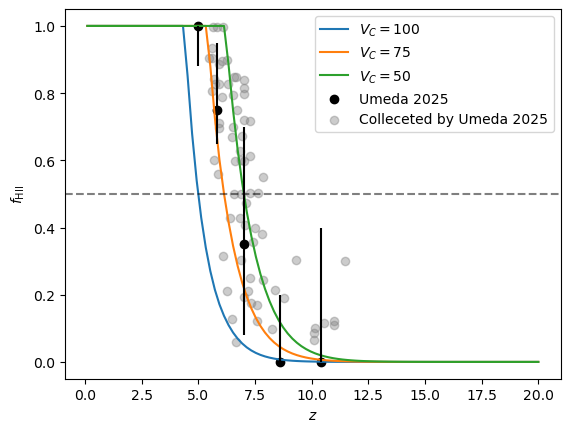

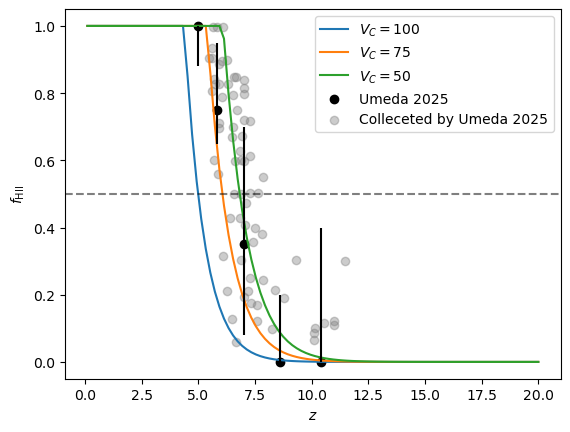

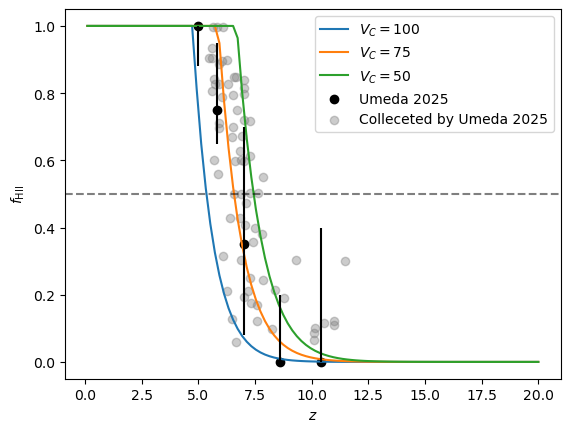

In [140]:
#Set 2 curves

plt.plot(z_range, SFRs_dataHaiman_2, label = r'$V_C=100$')
plt.plot(z_range, SFR2s_dataHaiman_2, label = r'$V_C=75$')
plt.plot(z_range, SFR3s_dataHaiman_2, label = r'$V_C=50$')
plt.xlabel(r'$z$')
plt.ylabel(r'$f_\text{HII}$')
plt.axhline(0.5, ls = '--', color = r'black', alpha = 0.5)
#plt.axvline(5, ls = '--', color = r'firebrick')
#plt.axvline(6, ls = '--', color = r'firebrick')
#plt.axvline(7, ls = '--', color = r'firebrick')

plt.scatter(z_lit_vals, f_HII_vals, color = r'Black', label = r'Umeda 2025')
plt.scatter(z_lit_vals2, f_HII_vals2, color = r'gray', alpha = 0.4, label = r'Colleceted by Umeda 2025')
plt.errorbar(z_lit_vals, f_HII_vals, yerr = np.array([Low_Err_f_HII, Upp_Err_f_HII]), color = r'black', fmt = ' ')
plt.legend()
plt.show()

plt.plot(z_range, SFRs_dataTest_2, label = r'$V_C=100$')
plt.plot(z_range, SFR2s_dataTest_2, label = r'$V_C=75$')
plt.plot(z_range, SFR3s_dataTest_2, label = r'$V_C=50$')
plt.xlabel(r'$z$')
plt.ylabel(r'$f_\text{HII}$')
plt.axhline(0.5, ls = '--', color = r'black', alpha = 0.5)
#plt.axvline(5, ls = '--', color = r'firebrick')
#plt.axvline(6, ls = '--', color = r'firebrick')
#plt.axvline(7, ls = '--', color = r'firebrick')

plt.scatter(z_lit_vals, f_HII_vals, color = r'Black', label = r'Umeda 2025')
plt.scatter(z_lit_vals2, f_HII_vals2, color = r'gray', alpha = 0.4, label = r'Colleceted by Umeda 2025')
plt.errorbar(z_lit_vals, f_HII_vals, yerr = np.array([Low_Err_f_HII, Upp_Err_f_HII]), color = r'black', fmt = ' ')
plt.legend()
plt.show()

plt.plot(z_range, SFRs_dataMadau_2, label = r'$V_C=100$')
plt.plot(z_range, SFR2s_dataMadau_2, label = r'$V_C=75$')
plt.plot(z_range, SFR3s_dataMadau_2, label = r'$V_C=50$')
plt.xlabel(r'$z$')
plt.ylabel(r'$f_\text{HII}$')
plt.axhline(0.5, ls = '--', color = r'black', alpha = 0.5)
#plt.axvline(5, ls = '--', color = r'firebrick')
#plt.axvline(6, ls = '--', color = r'firebrick')
#plt.axvline(7, ls = '--', color = r'firebrick')

plt.scatter(z_lit_vals, f_HII_vals, color = r'Black', label = r'Umeda 2025')
plt.scatter(z_lit_vals2, f_HII_vals2, color = r'gray', alpha = 0.4, label = r'Colleceted by Umeda 2025')
plt.errorbar(z_lit_vals, f_HII_vals, yerr = np.array([Low_Err_f_HII, Upp_Err_f_HII]), color = r'black', fmt = ' ')
plt.legend()
plt.show()

In [160]:
idx = np.where(SFRs_dataHaiman == 1)[0][-1]
z_reion = z_range[idx]

idx2 = np.where(SFR2s_dataHaiman == 1)[0][-1]
z_reion2 = z_range[idx2]

idx3 = np.where(SFR3s_dataHaiman == 1)[0][-1]
z_reion3 = z_range[idx3]

idx_Alt = np.where(SFRs_dataMadau_2 == 1)[0][-1]
z_reion_Alt = z_range[idx_Alt]

idx2_Alt = np.where(SFR2s_dataMadau_2 == 1)[0][-1]
z_reion2_Alt = z_range[idx2_Alt]

idx3_Alt = np.where(SFR3s_dataMadau_2 == 1)[0][-1]
z_reion3_Alt = z_range[idx3_Alt]

In [161]:
z_reion, z_reion2, z_reion3, z_reion_Alt, z_reion2_Alt, z_reion3_Alt

(np.float64(0.301010101010101),
 np.float64(5.125252525252525),
 np.float64(5.5272727272727264),
 np.float64(4.723232323232323),
 np.float64(5.728282828282827),
 np.float64(6.532323232323232))

In [162]:
#Our SFRD models:

integrand_SFRsHai = integrand(z_range, SFRs_dataHaiman)
integrand_SFR2sHai = integrand(z_range, SFR2s_dataHaiman)
integrand_SFR3sHai = integrand(z_range, SFR3s_dataHaiman)

integrand_SFRsMad_2 = integrand(z_range, SFRs_dataMadau_2)
integrand_SFR2sMad_2 = integrand(z_range, SFR2s_dataMadau_2)
integrand_SFR3sMad_2 = integrand(z_range, SFR3s_dataMadau_2)

In [163]:
TauSFRsHai = np.trapezoid(integrand_SFRsHai, z_range)
TauSFR2sHai = np.trapezoid(integrand_SFR2sHai, z_range)
TauSFR3sHai = np.trapezoid(integrand_SFR3sHai, z_range)

TauSFRsMad_2 = np.trapezoid(integrand_SFRsMad_2, z_range)
TauSFR2sMad_2 = np.trapezoid(integrand_SFR2sMad_2, z_range)
TauSFR3sMad_2 = np.trapezoid(integrand_SFR3sMad_2, z_range)

print(TauSFRsHai, TauSFR2sHai, TauSFR3sHai, TauSFRsMad_2, TauSFR2sMad_2, TauSFR3sMad_2)

0.005992524678174549 0.038108791706210704 0.04013602662299068 0.0309193890016306 0.041132699644602214 0.048832637695330895


## Literature SFRD Models

In [145]:
#Madau and Harikane:

def Madau(z):
    return 0.01 * (1+z)**2.6 / ( 1+((1+z)/3.2)**6.2 )
    
def Harikane(z):
    return 1 / ( 61.7 * (1+z)**(-3.13) + 10**(0.22*(1+z)) + 2.4 * 10**(0.5*(1+z)-3) )

def New_SFR(z): #Khaire
    return 10 ** (-2) * (2.01 + 8.48 * z) / (1 + (z / 2.5) ** 3.09)

def dN_dt_Mad(z):
    return Madau(z) * (1 + z) ** 3 * n_gamma * f_esc / m_p

def dN_dt_Har(z):
    return Harikane(z) * (1 + z) ** 3 * n_gamma * f_esc / m_p

def dN_dt_new(z):
    return New_SFR(z) * (1 + z) ** 3 * n_gamma * f_esc / m_p

Mad_dNdt = np.array([dN_dt_Mad(z) for z in z_range])
Har_dNdt = np.array([dN_dt_Har(z) for z in z_range])
New_dNdt = np.array([dN_dt_new(z) for z in z_range])

In [174]:
#f_esc = 0.2
def dN_dt_Mad_alt(z):
    return Madau(z) * (1 + z) ** 3 * n_gamma * f_esc / m_p

def dN_dt_Har_alt(z):
    return Harikane(z) * (1 + z) ** 3 * n_gamma * f_esc / m_p

def dN_dt_new_alt(z):
    return New_SFR(z) * (1 + z) ** 3 * n_gamma * f_esc / m_p

Mad_dNdt_alt = np.array([dN_dt_Mad_alt(z) for z in z_range])
Har_dNdt_alt = np.array([dN_dt_Har_alt(z) for z in z_range])
New_dNdt_alt = np.array([dN_dt_new_alt(z) for z in z_range])

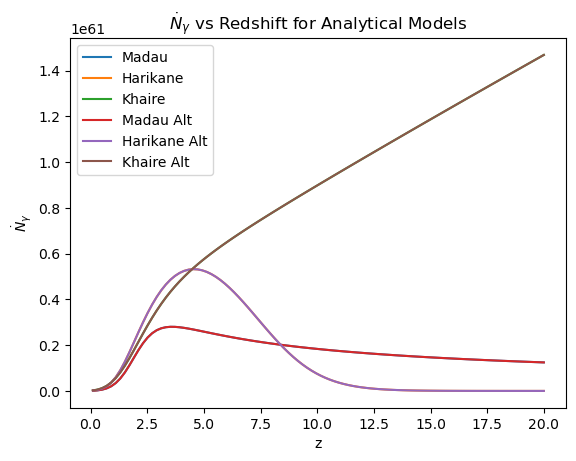

In [147]:
plt.plot(z_range, Mad_dNdt, label = r'Madau')
plt.plot(z_range, Har_dNdt, label = r'Harikane')
plt.plot(z_range, New_dNdt, label = r'Khaire')
plt.ylabel(r'$\dot{N}_\gamma$')
plt.xlabel(r'z')
plt.title(r'$\dot{N}_\gamma$ vs Redshift for Analytical Models')
plt.plot(z_range, Mad_dNdt_alt, label = r'Madau Alt')
plt.plot(z_range, Har_dNdt_alt, label = r'Harikane Alt')
plt.plot(z_range, New_dNdt_alt, label = r'Khaire Alt')
plt.legend()

In [148]:
def n_H(z):
    return X_H * Om_b * rho_c * (1 + z) ** 3 / m_p

def dt_dz(z):
    return -1 / ((1 + z) * H(z))

def Clump(z):
    #if z >= 6:
     #   return 1 + 9 * (7 / (1 + z)) ** 2
    #else:
     #   return 10
    #return 3
    return 2.9 * ((1 + z) / 6) ** (-1.1)

def Clump_new(z):
    if z >= 6:
        return 1 + 9 * (7 / (1 + z)) ** 3
    else:
        return 10

def Clump_test(z):
    return 3

def RHS_Mad(z, f_HII):
    return dN_dt_Mad(z) * dt_dz(z) / n_H(z) - alpha_B_unit * n_H(z) * f_HII * Clump(z) * dt_dz(z)

def RHS_Har(z, f_HII):
    return dN_dt_Har(z) * dt_dz(z) / n_H(z) - alpha_B_unit * n_H(z) * f_HII * Clump(z) * dt_dz(z)

def RHS_Har_new(z, f_HII):
    return dN_dt_Har_new(z) * dt_dz(z) / n_H(z) - alpha_B_unit * n_H(z) * f_HII * Clump(z) * dt_dz(z)

def RHS_New(z, f_HII):
    return dN_dt_new(z) * dt_dz(z) / n_H(z) - alpha_B_unit * n_H(z) * f_HII * Clump(z) * dt_dz(z)

def RHS_New_2(z, f_HII):
    return dN_dt_new(z) * dt_dz(z) / n_H(z) - alpha_B_unit * n_H(z) * f_HII * Clump_new(z) * dt_dz(z)

In [175]:
def RHS_Mad_Alt(z, f_HII):
    return dN_dt_Mad_alt(z) * dt_dz(z) / n_H(z) - alpha_B_unit * n_H(z) * f_HII * Clump_new(z) * dt_dz(z)

def RHS_Har_Alt(z, f_HII):
    return dN_dt_Har_alt(z) * dt_dz(z) / n_H(z) - alpha_B_unit * n_H(z) * f_HII * Clump_new(z) * dt_dz(z)
    
def RHS_New_Alt(z, f_HII):
    return dN_dt_new_alt(z) * dt_dz(z) / n_H(z) - alpha_B_unit * n_H(z) * f_HII * Clump_new(z) * dt_dz(z)

In [150]:
def RK4(f, x_0, y_0, h, x_n):
    steps = int(np.abs(np.abs(x_n - x_0) / h))
    x_arr = np.zeros(steps + 1)
    y_arr = np.zeros_like(x_arr)
    
    x_arr[0] = x_0
    y_arr[0] = y_0
    counter = 0

    for i in range(1, steps + 1):
        counter += 1
        k_1 = f(x_arr[i - 1], y_arr[i - 1])
        k_2 = f(x_arr[i - 1] + h / 2, y_arr[i - 1] + h * k_1 / 2)
        k_3 = f(x_arr[i - 1] + h / 2, y_arr[i - 1] + h * k_2 / 2)
        k_4 = f(x_arr[i - 1] + h, y_arr[i - 1] + h * k_3)

        y_arr[i] = y_arr[i - 1] + h * (k_1 + 2 * k_2 + 2 * k_3 + k_4) / 6
        x_arr[i] = x_arr[i - 1] + h

        if y_arr[i] >= 1:
            for j in range(counter, steps + 1):
                y_arr[j] = 1
                x_arr[j] = x_arr[j - 1] + h
            break
    return x_arr, y_arr

In [176]:
Mad_data = RK4(RHS_Mad, 20, 0, -0.1, 0.01)
Har_data = RK4(RHS_Har, 20, 0, -0.1, 0.01)
New_data = RK4(RHS_New, 20, 0, -0.1, 0.01)

Mad_data_Alt = RK4(RHS_Mad_Alt, 20, 0, -0.1, 0.01)
Har_data_Alt = RK4(RHS_Har_Alt, 20, 0, -0.1, 0.01)
New_data_Alt = RK4(RHS_New_Alt, 20, 0, -0.1, 0.01)

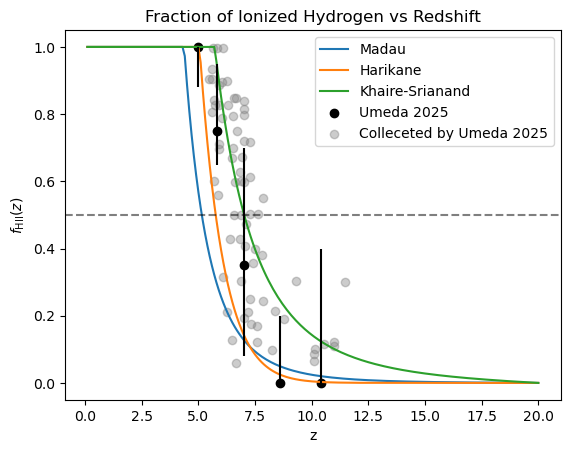

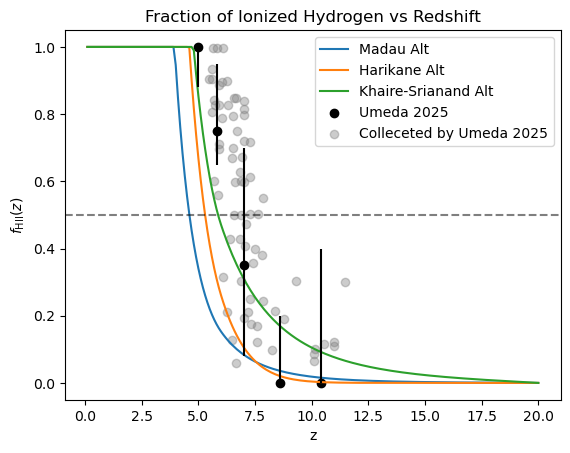

In [177]:
plt.plot(Mad_data[0], Mad_data[1], label = r'Madau')
plt.plot(Har_data[0], Har_data[1], label = r'Harikane')
plt.plot(New_data[0], New_data[1], label = r'Khaire-Srianand')
#plt.plot(Har_data_2[0], Har_data_2[1], label = r'Harikane')
#plt.plot(New_data_2[0], New_data_2[1], label = r'New Model')
plt.ylabel(r'$f_{\text{HII}}(z)$')
plt.xlabel(r'z')
plt.title(r'Fraction of Ionized Hydrogen vs Redshift')
#plt.axvline(5, ls = '--', color = r'firebrick')
#plt.axvline(6, ls = '--', color = r'firebrick')
#plt.axvline(7, ls = '--', color = r'firebrick')
plt.axhline(0.5, ls = '--', color = r'black', alpha = 0.5)

plt.scatter(z_lit_vals, f_HII_vals, color = r'Black', label = r'Umeda 2025')
plt.scatter(z_lit_vals2, f_HII_vals2, color = r'gray', alpha = 0.4, label = r'Colleceted by Umeda 2025')
plt.errorbar(z_lit_vals, f_HII_vals, yerr = np.array([Low_Err_f_HII, Upp_Err_f_HII]), color = r'black', fmt = ' ')
plt.legend()
plt.show()

plt.plot(Mad_data_Alt[0], Mad_data_Alt[1], label = r'Madau Alt')
plt.plot(Har_data_Alt[0], Har_data_Alt[1], label = r'Harikane Alt')
plt.plot(New_data_Alt[0], New_data_Alt[1], label = r'Khaire-Srianand Alt')
plt.ylabel(r'$f_{\text{HII}}(z)$')
plt.xlabel(r'z')
plt.title(r'Fraction of Ionized Hydrogen vs Redshift')
#plt.axvline(5, ls = '--', color = r'firebrick')
#plt.axvline(6, ls = '--', color = r'firebrick')
#plt.axvline(7, ls = '--', color = r'firebrick')

plt.scatter(z_lit_vals, f_HII_vals, color = r'Black', label = r'Umeda 2025')
plt.scatter(z_lit_vals2, f_HII_vals2, color = r'gray', alpha = 0.4, label = r'Colleceted by Umeda 2025')
plt.errorbar(z_lit_vals, f_HII_vals, yerr = np.array([Low_Err_f_HII, Upp_Err_f_HII]), color = r'black', fmt = ' ')
plt.legend()
plt.axhline(0.5, ls = '--', color = r'black', alpha = 0.5)

#plt.axvline(7.7, ls = '--')
#plt.axvline(7, color = r'black')

plt.show()

In [153]:
idx = np.where(Mad_data[1] == 1)[0][0]
z_reion = Mad_data[0][idx]

idx2 = np.where(Har_data[1] == 1)[0][0]
z_reion2 = Har_data[0][idx2]

idx3 = np.where(New_data[1] == 1)[0][0]
z_reion3 = New_data[0][idx3]

idx_Alt = np.where(Mad_data_Alt[1] == 1)[0][0]
z_reion_Alt = Mad_data_Alt[0][idx_Alt]

idx2_Alt = np.where(Har_data_Alt[1] == 1)[0][0]
z_reion2_Alt = Har_data_Alt[0][idx2_Alt]

idx3_Alt = np.where(New_data_Alt[1] == 1)[0][0]
z_reion3_Alt = New_data_Alt[0][idx3_Alt]

In [154]:
z_reion, z_reion2, z_reion3, z_reion_Alt, z_reion2_Alt, z_reion3_Alt

(np.float64(4.2999999999999865),
 np.float64(4.999999999999984),
 np.float64(5.6999999999999815),
 np.float64(3.899999999999987),
 np.float64(4.499999999999986),
 np.float64(4.699999999999985))

# Thomson Optical Depth Calculations

Thomson optical depth is given as:

$$\int_0^\infty n_\text{e}(z)\sigma_\text{T}c\left|\frac{\text{d}t}{\text{d}z}\right|\text{d}z$$

where:

$$n_\text{e}(z)=f_\text{HII}(z)n_\text{H}(z)$$

and $\sigma_\text{T}=6.65\times10^{-25}\text{ cm}^{2}$ is the Thomson scattering cross-section.

In [155]:
m_p = 8.41 * 10 ** (-58) #SM
c_light = 3 * 10 ** 5 #km/s

def H_units(z): #in km/s/Mpc
    return H(z) / (3.154 * 10 ** (7)) * (3.086 * 10 ** 19)

sigma_T = 6.65 * 10 ** (-25) * (3.24 * 10 ** (-25)) ** 2

In [156]:
#Defining the integrand
def n_e(z, f_HII):
    return f_HII * 0.75 * Om_b * rho_c * (1+z)**3 / (m_p)

def integrand(z, f_HII):
    integrand_vals = np.zeros(len(z))
    for i in range(len(z)):
        integrand_vals[i] = n_e(z[i], f_HII[i]) * sigma_T * c_light * 1 / ((1 + z[i]) * H_units(z[i]))
    return integrand_vals

In [157]:
#Our SFRD models:

integrand_SFRsMad = integrand(z_range, SFRs_dataHaiman)
integrand_SFR2sMad = integrand(z_range, SFR2s_dataHaiman)
integrand_SFR3sMad = integrand(z_range, SFR3s_dataHaiman)

#Literature SFRD models:

#integrand_Mad = integrand(z_range, Mad_data[1][::-1])
#integrand_Har = integrand(z_range, Har_data[1][::-1])
#integrand_New = integrand(z_range, New_data[1][::-1])

#integrand_Mad_Alt = integrand(z_range, Mad_data_Alt[1][::-1])
#integrand_Har_Alt = integrand(z_range, Har_data_Alt[1][::-1])
#integrand_New_Alt = integrand(z_range, New_data_Alt[1][::-1])

NameError: name 'integrand_Mad' is not defined

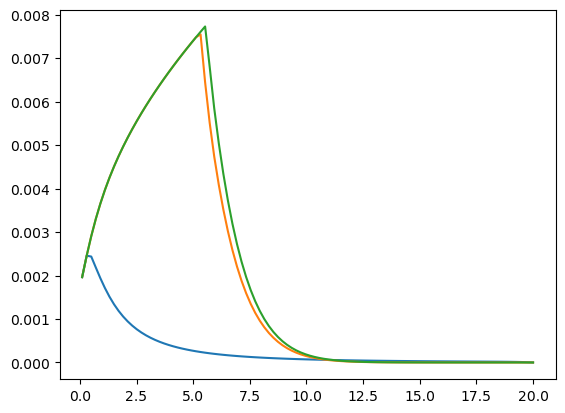

In [158]:
plt.plot(z_range, integrand_SFRsMad, label = r'Vc=100')
plt.plot(z_range, integrand_SFR2sMad, label = r'Vc=75')
plt.plot(z_range, integrand_SFR3sMad, label = r'Vc=50')
plt.plot(z_range, integrand_Mad, label = r'Mad')
plt.plot(z_range, integrand_Har, label = r'Har')
plt.plot(z_range, integrand_New, label = r'Khair')
plt.xlabel(r'$z$')
plt.ylabel(r'$n_H(z)\sigma_Tcf_{HII}(z)\frac{dt}{dz}(z)$')
plt.legend()

In [ ]:
TauSFRsMad = np.trapezoid(integrand_SFRsMad, z_range)
TauSFR2sMad = np.trapezoid(integrand_SFR2sMad, z_range)
TauSFR3sMad = np.trapezoid(integrand_SFR3sMad, z_range)

#TauMad = np.trapezoid(integrand_Mad, z_range)
#TauHar = np.trapezoid(integrand_Har, z_range)
#TauNew = np.trapezoid(integrand_New, z_range)

#TauMad_Alt = np.trapezoid(integrand_Mad_Alt, z_range)
#TauHar_Alt = np.trapezoid(integrand_Har_Alt, z_range)
#TauNew_Alt = np.trapezoid(integrand_New_Alt, z_range)

print(TauMad, TauSFR2sMad, TauSFR3sMad) #TauMad, TauHar, TauNew, TauMad_Alt, TauHar_Alt, TauNew_Alt)